# V46: Low-Turnover Strategy - Regime-Based Buy & Hold (LQ45)

Notebook ini memperkenalkan efisiensi biaya yang jauh lebih tinggi dengan mengubah frekuensi rebalancing.

### Perubahan Logika Kolektif:
1. **Hold-During-Regime**: Graph Filter dan Markowitz Optimization hanya dijalankan **sekali** saat AI berubah sinyal dari Risk-Off ke Risk-On. 
2. **No Daily Rebalancing**: Selama AI tetap memberikan sinyal Risk-On, kita tidak melakukan rebalancing harian. Kita menahan saham-saham yang sudah dipilih sampai AI memberikan sinyal Risk-Off (CASH).
3. **Extreme Cost Efficiency**: Dengan cara ini, biaya transaksi hanya dibayarkan saat "Masuk" dan "Keluar" dari pasar, bukan setiap hari. Ini akan sangat membantu performa pada pasar dengan fee tinggi (0.25%).

In [7]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [8]:
# --- 2. AI Training (SMA Crossover Target) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

In [9]:
# --- 3. Optimization Functions ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    res = minimize(lambda w: -np.sum(w * mu) / np.sqrt(np.dot(w.T, np.dot(sigma, w))) if np.dot(w.T, np.dot(sigma, w)) > 0.0001 else 0,
                   [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

In [10]:
# --- 4. Low-Turnover Simulation Logic ---

def run_low_turnover_simulation(test_dates, returns, ai_probs, threshold, fee=0.0025, g_lookback=60):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    prev_weights = {} # Bobot hari sebelumnya
    current_weights = {'CASH': 1.0} # Bobot saat ini
    
    risk_status = False
    buffer = 0.05
    
    selection_log = []
    
    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        
        # Tentukan apakah status berubah
        old_status = risk_status
        if not risk_status and prob > (threshold + buffer): risk_status = True
        elif risk_status and prob < (threshold - buffer): risk_status = False
        
        # LOGIKA KRUSIAL: Hanya rebalancing jika status berubah atau baru mulai
        status_changed = (old_status != risk_status)
        
        if status_changed:
            if not risk_status:
                # Berubah ke RISK-OFF (CASH)
                current_weights = {'CASH': 1.0}
            else:
                # Berubah ke RISK-ON (Hitung Portfolio Baru)
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected_stocks = get_mis_assets(window_rets)
                current_weights = optimize_markowitz(window_rets[selected_stocks])
        else:
            # JIKA STATUS TIDAK BERUBAH: Gunakan bobot yang sama dengan sebelumnya (Buy & Hold)
            # Target weights tidak diupdate sehingga turnover = 0
            pass
        
        # Hitung Turnover Cost harian
        all_assets = set(list(current_weights.keys()) + list(prev_weights.keys()))
        # Jika current_weights sama dengan prev_weights, turnover adalah 0
        turnover = sum(abs(current_weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        
        cost = val * turnover * fee
        val -= cost
        
        # PnL untuk esok hari
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in current_weights else sum(w * returns.loc[next_date, a] for a, w in current_weights.items())
        val *= (1 + day_ret)
        
        history.append(val)
        dates.append(next_date)
        
        # Simpan log
        selection_log.append({
            'Date': date,
            'Risk_Status': 'Risk-On' if risk_status else 'Risk-Off',
            'Is_Rebalanced': status_changed,
            'Turnover': turnover,
            'Portfolio_Value': val
        })
        
        prev_weights = current_weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), pd.DataFrame(selection_log)

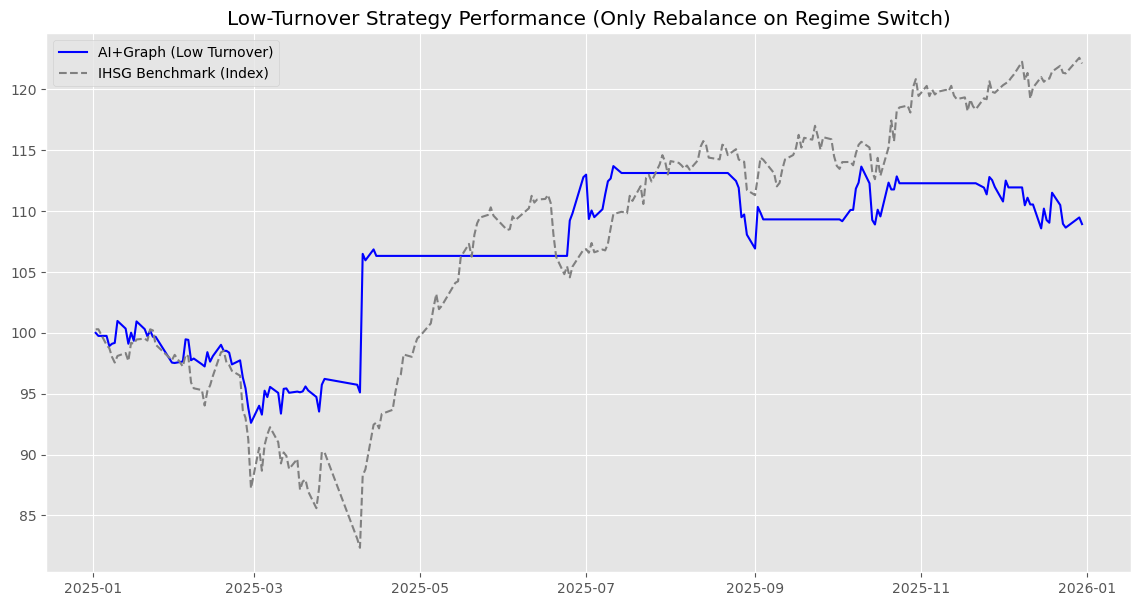

Total Rebalancing Events: 34
Average Daily Turnover: 0.2936


In [11]:
# --- 5. Run & Visualization ---
test_dates = test_probs.index
val_history, log_df = run_low_turnover_simulation(test_dates, returns, test_probs, opt_t)

benchmark = (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)

plt.figure(figsize=(14, 7))
plt.plot(val_history.index, val_history['Portfolio_Value'], label='AI+Graph (Low Turnover)', color='blue')
plt.plot(benchmark.index, benchmark, label='IHSG Benchmark (Index)', color='gray', linestyle='--')

plt.title("Low-Turnover Strategy Performance (Only Rebalance on Regime Switch)")
plt.legend()
plt.show()

print(f"Total Rebalancing Events: {log_df['Is_Rebalanced'].sum()}")
print(f"Average Daily Turnover: {log_df['Turnover'].mean():.4f}")

In [12]:
# --- 6. Export Results ---
output_file = 'v21_low_turnover_backtest_2025.xlsx'
with pd.ExcelWriter(output_file) as writer:
    val_history.to_excel(writer, sheet_name='Equity_Curve')
    log_df.to_excel(writer, sheet_name='Simulation_Log', index=False)

print(f"✓ Results exported to {output_file}")

✓ Results exported to v21_low_turnover_backtest_2025.xlsx
